In [1]:
import pandas as pd
import pickle
from pathlib import Path
import os
import pandas as pd
import scanpy as sc
import cellink as cl
from cellink.tl._burden_testing import *

/opt/modules/i12g/anaconda/envs/mzb_scgenetics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read all results for chr 14-22

In [3]:
chr1_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr1_all_results.pkl")
chr2_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr2_all_results.pkl")
chr3_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr3_all_results.pkl")
chr4_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr4_all_results.pkl")
chr5_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr5_all_results.pkl")
chr6_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr6_all_results.pkl")
chr7_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr7_all_results.pkl")
chr8_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr8_all_results.pkl")
chr9_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr9_all_results.pkl")
chr10_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr10_all_results.pkl")
chr11_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr11_all_results.pkl")
chr12_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr12_all_results.pkl")
chr13_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr13_all_results.pkl")
chr14_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr14_all_results.pkl")
chr15_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr15_all_results.pkl")
chr16_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr16_all_results.pkl")
chr17_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr17_all_results.pkl")
chr18_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr18_all_results.pkl")
chr19_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr19_all_results.pkl")
chr20_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr20_all_results.pkl")
chr21_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr21_all_results.pkl")
chr22_all_results=pd.read_pickle("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/chr22_all_results.pkl")


### filter for DNA_LM_mixed_only

In [4]:
all_results = pd.concat([chr1_all_results, 
                    chr2_all_results,
                   chr3_all_results,
                   chr4_all_results,
                   chr5_all_results,
                    chr6_all_results, 
                    chr7_all_results,
                   chr8_all_results,
                   chr9_all_results,
                   chr10_all_results,
                    chr11_all_results,
                   chr12_all_results,
                   chr13_all_results,
                    chr14_all_results, 
                    chr15_all_results,
                   chr16_all_results,
                   chr17_all_results,
                   chr18_all_results,
                   chr19_all_results,
                   chr20_all_results,
                   chr21_all_results,
                   chr22_all_results,], ignore_index=True)
all_results

,burden_gene,target_gene,burden_type,pvalue,beta,cell_type,chromosome
0,ENSG00000228463,ENSG00000228463,DNA_LM_up,0.104385,-0.004979,CD8 ET,1
1,ENSG00000228463,ENSG00000228463,DNA_LM_down,0.125772,-0.004695,CD8 ET,1
2,ENSG00000228463,ENSG00000228463,DNA_LM_mixed,0.125772,-0.004695,CD8 ET,1
3,ENSG00000228327,ENSG00000228327,DNA_LM_up,0.184396,0.002299,CD8 ET,1
4,ENSG00000228327,ENSG00000228327,DNA_LM_down,0.171339,0.002370,CD8 ET,1
...,...,...,...,...,...,...,...
443476,ENSG00000100300,ENSG00000100300,DNA_LM_down,0.920155,-0.016040,Erythrocytes,22
443477,ENSG00000100300,ENSG00000100300,DNA_LM_mixed,0.990922,0.001820,Erythrocytes,22
443478,ENSG00000170638,ENSG00000170638,DNA_LM_up,0.042310,0.346326,Erythrocytes,22
443479,ENSG00000170638,ENSG00000170638,DNA_LM_down,0.029698,0.369519,Erythrocytes,22


In [5]:
all_results_mixed = all_results[all_results["burden_type"]=="DNA_LM_mixed"]
all_results_mixed

,burden_gene,target_gene,burden_type,pvalue,beta,cell_type,chromosome
2,ENSG00000228463,ENSG00000228463,DNA_LM_mixed,0.125772,-0.004695,CD8 ET,1
5,ENSG00000228327,ENSG00000228327,DNA_LM_mixed,0.171842,0.002368,CD8 ET,1
8,ENSG00000237491,ENSG00000237491,DNA_LM_mixed,0.987381,-0.000026,CD8 ET,1
11,ENSG00000225880,ENSG00000225880,DNA_LM_mixed,0.397880,-0.001725,CD8 ET,1
14,ENSG00000230368,ENSG00000230368,DNA_LM_mixed,0.572912,0.001421,CD8 ET,1
...,...,...,...,...,...,...,...
443468,ENSG00000100138,ENSG00000100138,DNA_LM_mixed,0.845545,-0.035432,Erythrocytes,22
443471,ENSG00000183172,ENSG00000183172,DNA_LM_mixed,0.113366,0.173582,Erythrocytes,22
443474,ENSG00000184983,ENSG00000184983,DNA_LM_mixed,0.057143,-0.327124,Erythrocytes,22
443477,ENSG00000100300,ENSG00000100300,DNA_LM_mixed,0.990922,0.001820,Erythrocytes,22


### correcting p values

In [68]:
from statsmodels.stats.multitest import multipletests
def FDR_correction(association_results):
    """
    association_results: pd.DataFrame, results from burden_test/ output written in run_burden_ass.py
    
    returns: - df_final: pd.DataFrame, association_results, sorted by celltype and burden type
                                        added column "FDR corrected" values and "significant"
             - df_to_plot: pd.DataFrame, summary of # significant egenes per cell type and burden type
    """
   
    df=association_results.copy()
    df_to_plot = pd.DataFrame(columns=['celltype', 'annotation', 'n'])
    
    df_final=[]
    for celltype in df["cell_type"].unique():
        df_annotations={}
        for annotation in df["burden_type"].unique():
            df_annotations[annotation] = df[(df["cell_type"] == celltype) & (df["burden_type"]==annotation)]
            df_annotations[annotation] = df_annotations[annotation].dropna(how='all')
            # FDR correction
            df_annotations[annotation]["significant"], df_annotations[annotation]["FDR_corrected"], _, _ = multipletests(df_annotations[annotation]["pvalue"], alpha=0.05, method='fdr_bh')
            
            df_to_plot = pd.concat([df_to_plot, pd.DataFrame({
                    'celltype': [celltype],
                    'annotation': [annotation],
                    'n': [len(df_annotations[annotation][df_annotations[annotation]["significant"]])]
                })], ignore_index=True)
            df_annotations[annotation]["celltype-annotation"]= f"{celltype}-{annotation}"
            df_final.append(df_annotations[annotation]) 
            
    df_final=pd.concat(df_final)
    
    df_to_plot['celltype_annotation'] = df_to_plot['celltype'] + "_" + df_to_plot['annotation']
    df_to_plot
    return df_final, df_to_plot

from plotnine import *
def plot_egenes(df_to_plot):
    """
    df_to_plot: pd.DataFrame, as output[1] of  FDR_correction()
    returns: plot, grouped barplot # egenes per cell type and burden
    """
    zero_types = list(df_to_plot.query("n==0")["celltype_annotation"])
    # Filter out the rows where `n` is 0 and create the plot
    plot = (
        ggplot(df_to_plot.query("celltype_annotation not in @zero_types"), 
               aes(x='celltype', y='n', fill='annotation'))  # Specify x, y, and fill variables
        + geom_bar(stat="identity", position="dodge")  # Use position="dodge" for grouped bars
        + theme_classic()  # Optional: use a clean theme
        + theme(
            axis_text_x=element_text(angle=45, hjust=1, vjust=1),
            figure_size=(10, 5)
        )
        + labs(
            y="Number of E-Genes", 
            x="", 
            fill="Burden Annotation"
        )
        # Optional: Customize colors manually
        # + scale_fill_manual(values=['darkred', "grey", "blue", "green"], 
        #     labels=["GENE_TSS_DISTANCE", "GENE_TSS_DISTANCE_SAIGE", "CADD_PHRED", "DNA_LM_down","DNA_LM_up","DNA_LM_mixed", "MAF_beta_1.25"])
    )
    return(plot)


In [10]:
df_to_plot

,celltype,annotation,n,celltype_annotation
0,CD8 ET,DNA_LM_mixed,1,CD8 ET_DNA_LM_mixed
1,CD8 NC,DNA_LM_mixed,0,CD8 NC_DNA_LM_mixed
2,CD4 NC,DNA_LM_mixed,14,CD4 NC_DNA_LM_mixed
3,Mono C,DNA_LM_mixed,40,Mono C_DNA_LM_mixed
4,NK,DNA_LM_mixed,8,NK_DNA_LM_mixed
5,B IN,DNA_LM_mixed,10,B IN_DNA_LM_mixed
6,CD4 ET,DNA_LM_mixed,4,CD4 ET_DNA_LM_mixed
7,Mono NC,DNA_LM_mixed,23,Mono NC_DNA_LM_mixed
8,CD8 S100B,DNA_LM_mixed,4,CD8 S100B_DNA_LM_mixed
9,B Mem,DNA_LM_mixed,4,B Mem_DNA_LM_mixed


In [8]:
df_final, df_to_plot = FDR_correction(all_results_mixed)

In [11]:
all_results_mixed.to_csv('/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/all_results_mixed_new.csv', index=False) 

In [12]:
df_final.to_csv('/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/all_results_FDR_corrected_mixed_new.csv', index=False) 

In [41]:
df_to_plot_filtered =df_to_plot[~df_to_plot["celltype"].isin(["Erythrocytes", "Platelets"])]

In [13]:
df_to_plot.to_csv('/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/all_results_summary_mixed_new.csv', index=False) 

[2025-01-30 07:56:44,257] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


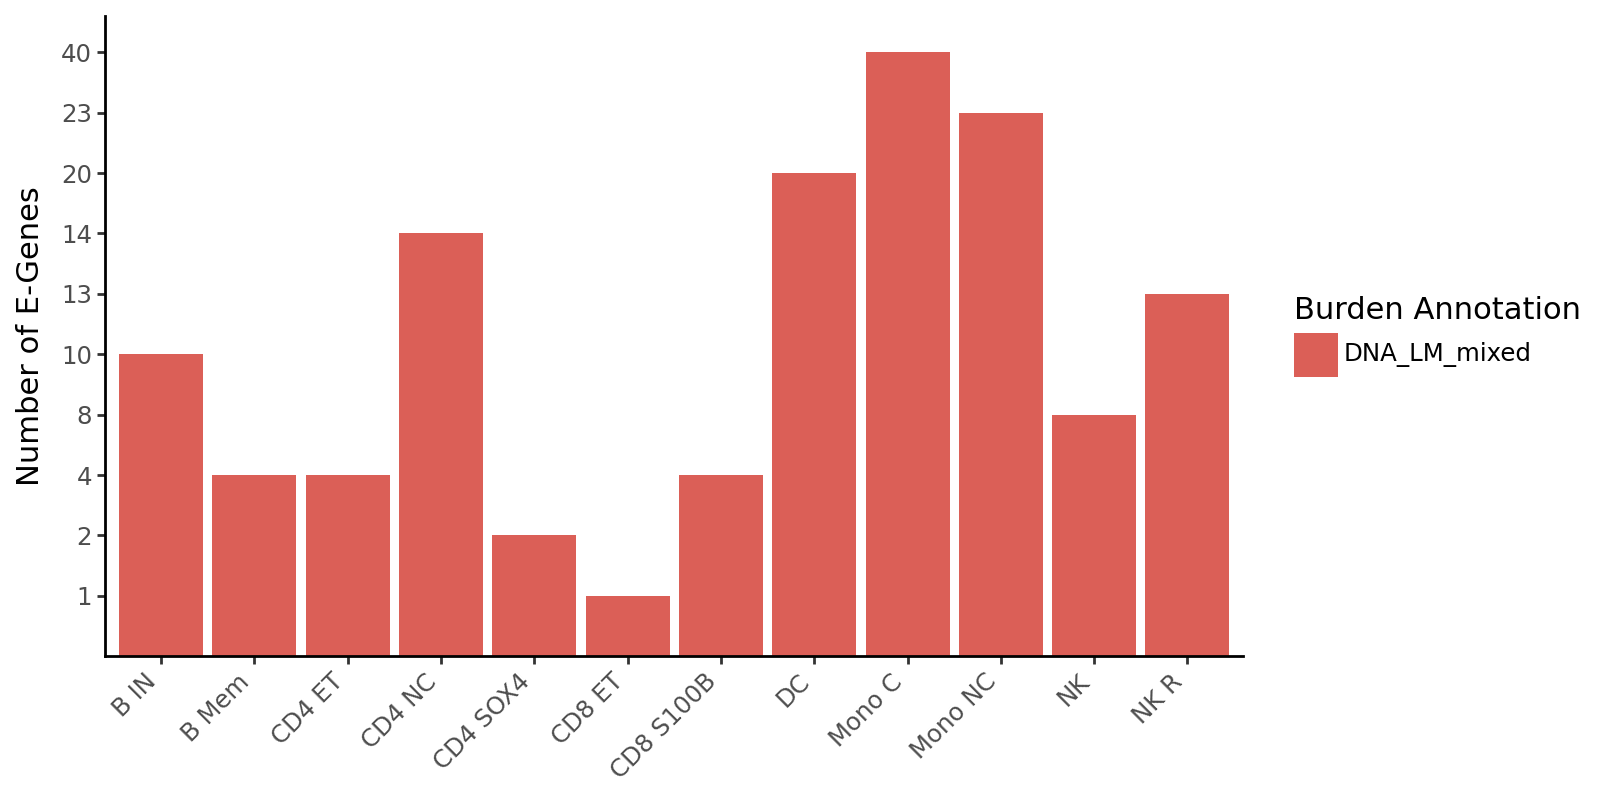

In [14]:
plot_egenes(df_to_plot)

## read all other data

In [28]:
all_results_before =pd.read_csv('/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association/all_results_FDR_corrected.csv')


In [35]:
df_final["burden_type"]="DNA_LM_mixed_new"
df_to_plot["annotation"]="DNA_LM_mixed_new"

In [36]:

all_results_comb = pd.concat([all_results_before, 
                            df_final], ignore_index=True)
all_results_comb

,burden_gene,target_gene,burden_type,pvalue,beta,cell_type,chromosome,significant,FDR_corrected,celltype-annotation
0,ENSG00000228463,ENSG00000228463,CADD_PHRED,0.393581,-0.004054,CD8 ET,1,False,0.955526,CD8 ET-CADD_PHRED
1,ENSG00000228327,ENSG00000228327,CADD_PHRED,0.348254,-0.002507,CD8 ET,1,False,0.947938,CD8 ET-CADD_PHRED
2,ENSG00000237491,ENSG00000237491,CADD_PHRED,0.617412,-0.001265,CD8 ET,1,False,0.979683,CD8 ET-CADD_PHRED
3,ENSG00000225880,ENSG00000225880,CADD_PHRED,0.924011,-0.000300,CD8 ET,1,False,0.997450,CD8 ET-CADD_PHRED
4,ENSG00000230368,ENSG00000230368,CADD_PHRED,0.532657,0.002424,CD8 ET,1,False,0.970296,CD8 ET-CADD_PHRED
...,...,...,...,...,...,...,...,...,...,...
1182611,ENSG00000100138,ENSG00000100138,DNA_LM_mixed_new,0.845545,-0.035432,Erythrocytes,22,False,0.961233,Erythrocytes-DNA_LM_mixed
1182612,ENSG00000183172,ENSG00000183172,DNA_LM_mixed_new,0.113366,0.173582,Erythrocytes,22,False,0.852378,Erythrocytes-DNA_LM_mixed
1182613,ENSG00000184983,ENSG00000184983,DNA_LM_mixed_new,0.057143,-0.327124,Erythrocytes,22,False,0.788862,Erythrocytes-DNA_LM_mixed
1182614,ENSG00000100300,ENSG00000100300,DNA_LM_mixed_new,0.990922,0.001820,Erythrocytes,22,False,0.997246,Erythrocytes-DNA_LM_mixed


In [37]:
df_to_plot_before = pd.read_csv('/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association/all_results_summary.csv')

df_to_plot_comb = pd.concat([df_to_plot_before, 
                            df_to_plot], ignore_index=True)
df_to_plot_comb

,celltype,annotation,n,celltype_annotation
0,CD8 ET,CADD_PHRED,27,CD8 ET_CADD_PHRED
1,CD8 ET,DNA_LM_up,1,CD8 ET_DNA_LM_up
2,CD8 ET,DNA_LM_down,1,CD8 ET_DNA_LM_down
3,CD8 ET,MAF_beta_1.25,19,CD8 ET_MAF_beta_1.25
4,CD8 ET,DNA_LM_mixed,7,CD8 ET_DNA_LM_mixed
...,...,...,...,...
123,DC,DNA_LM_mixed_new,20,DC_DNA_LM_mixed
124,NK R,DNA_LM_mixed_new,13,NK R_DNA_LM_mixed
125,Platelets,DNA_LM_mixed_new,0,Platelets_DNA_LM_mixed
126,CD4 SOX4,DNA_LM_mixed_new,2,CD4 SOX4_DNA_LM_mixed


[2025-01-30 10:03:17,009] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


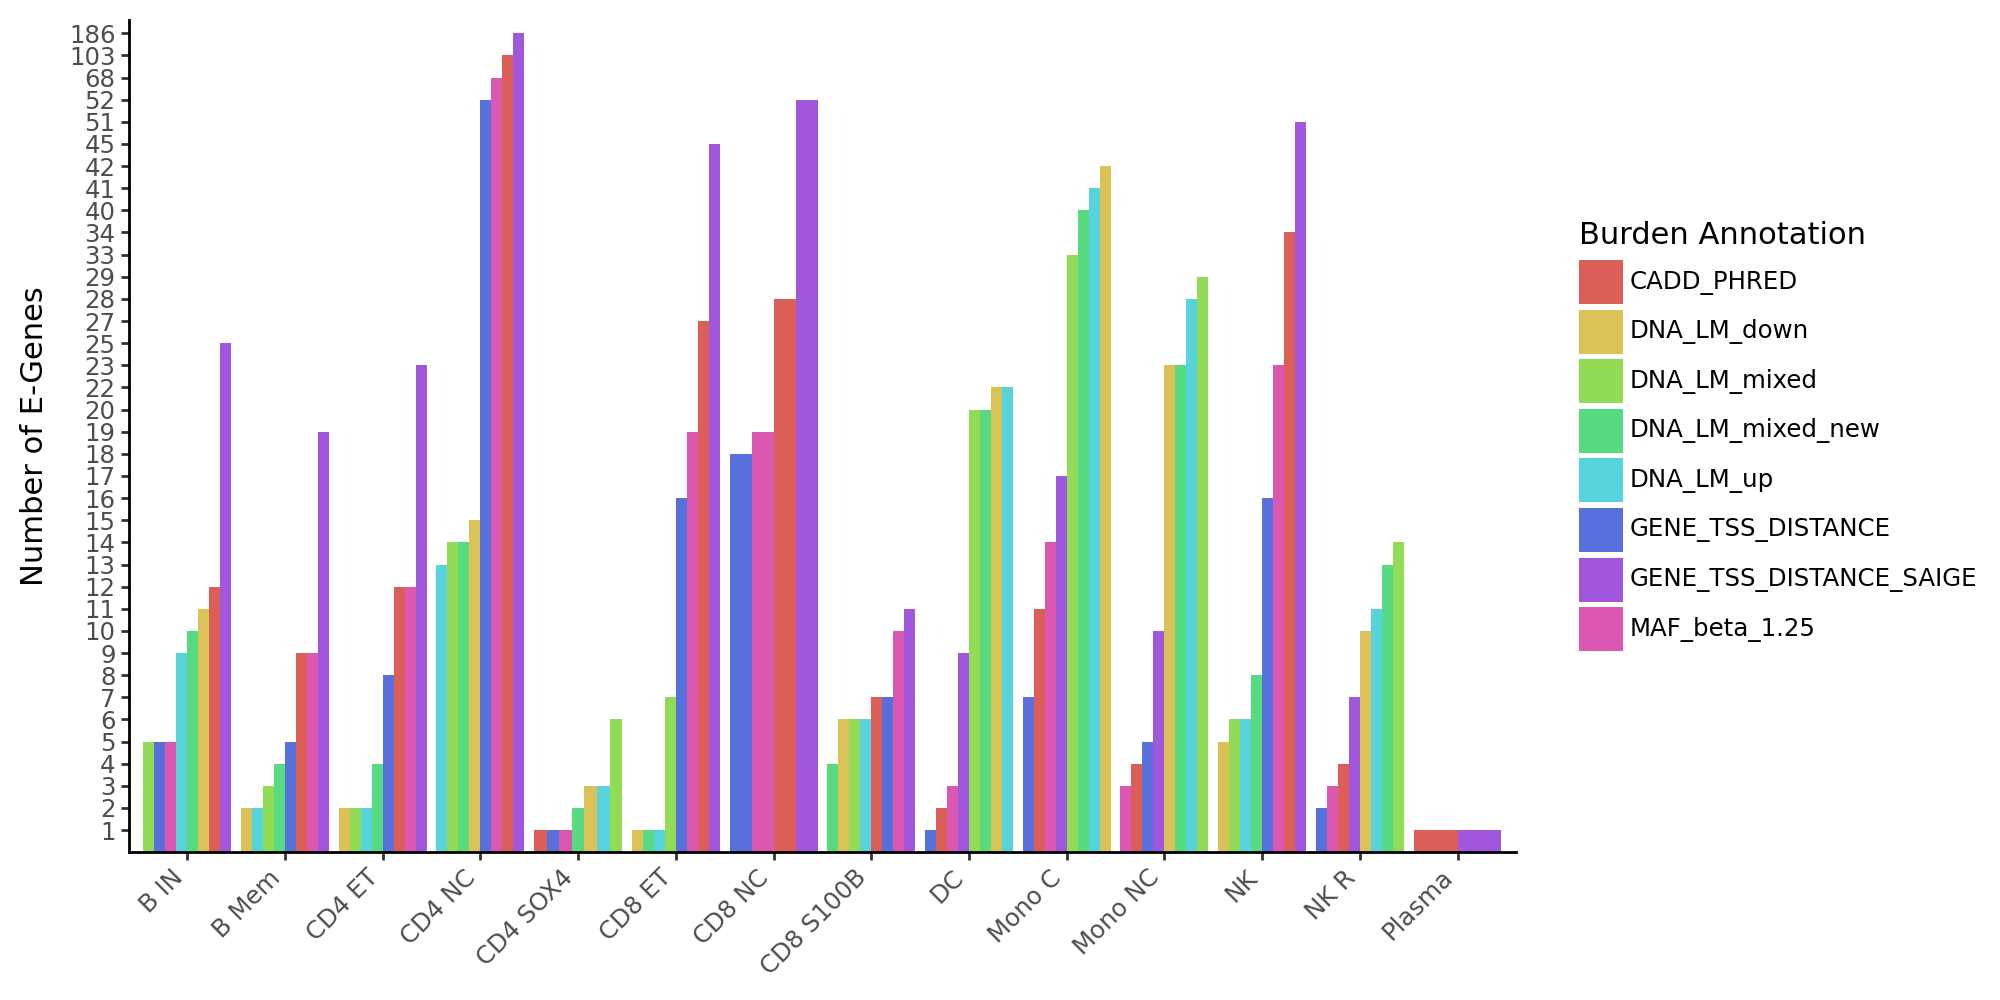

In [71]:
plot_egenes(df_to_plot_comb[~df_to_plot_comb["celltype"].isin(["Platelets", "Erythrocytes"])])

[2025-01-30 09:58:14,500] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


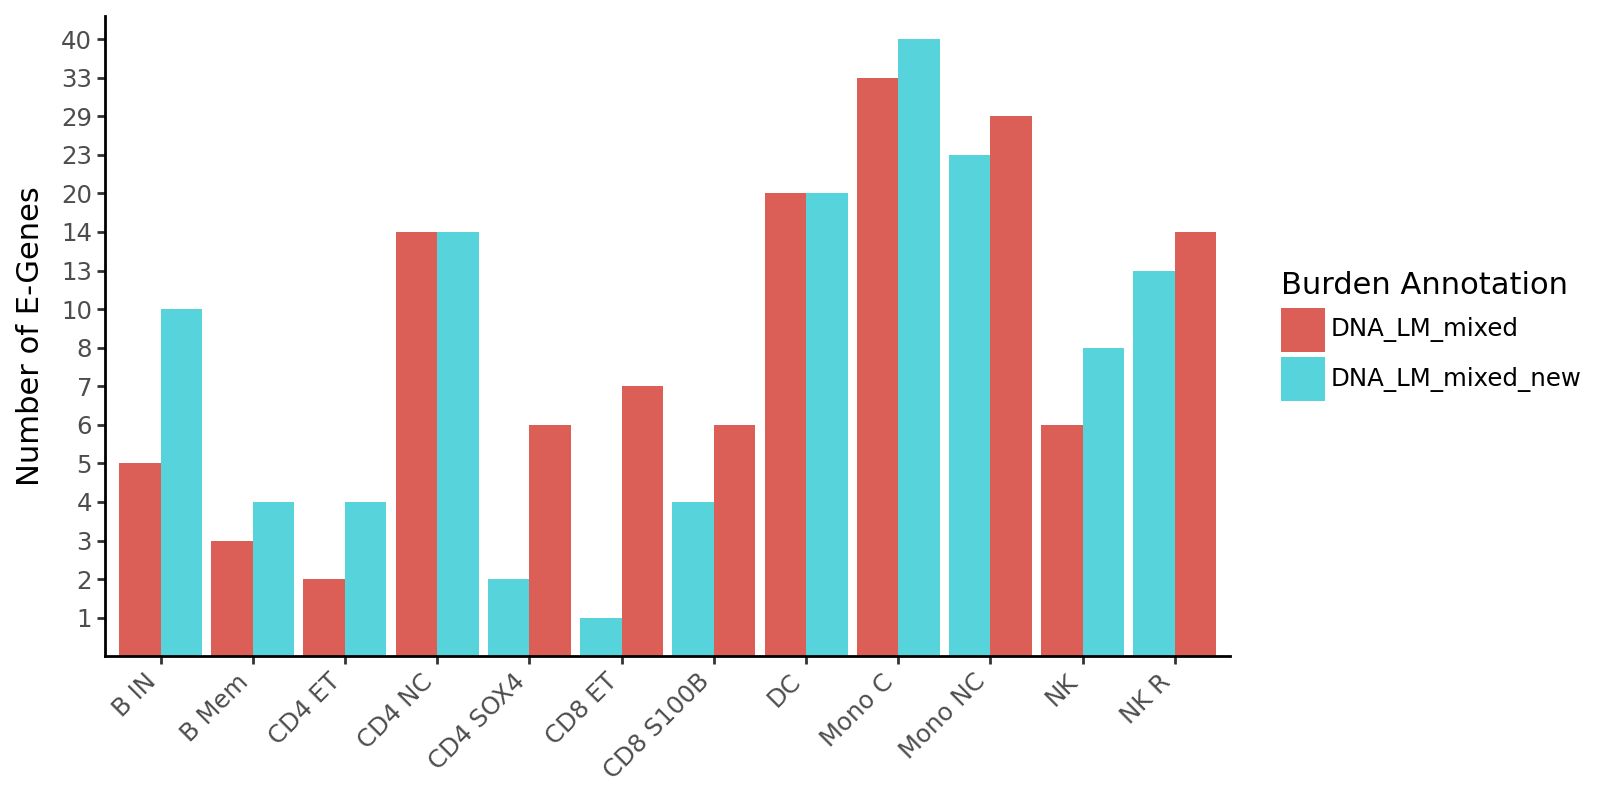

In [67]:
new_vs_old =df_to_plot_comb[df_to_plot_comb["annotation"].isin(["DNA_LM_mixed", 
                                                                "DNA_LM_mixed_new"#,
                                                                #"DNA_LM_up",
                                                                #"DNA_LM_down"
                                                               ])]
plot_egenes(new_vs_old)

In [49]:
print(sum(new_vs_old[new_vs_old["annotation"]=="DNA_LM_mixed"]["n"]))
print(sum(new_vs_old[new_vs_old["annotation"]=="DNA_LM_mixed_new"]["n"]))
print(sum(new_vs_old[new_vs_old["annotation"]=="DNA_LM_up"]["n"]))
print(sum(new_vs_old[new_vs_old["annotation"]=="DNA_LM_down"]["n"]))

149
143
144
142


In [42]:
all_results_comb.to_csv('/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/all_results_FDR_comb.csv', index=False) 
df_to_plot_comb.to_csv('/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/association2/all_results_summary_comb.csv', index=False) 


In [52]:
all_burdens_old = pd.read_parquet('/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens/all_burdens.parquet')

chr1_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr1_all_burdens.parquet")
chr2_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr2_all_burdens.parquet")
chr3_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr3_all_burdens.parquet")
chr4_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr4_all_burdens.parquet")
chr5_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr5_all_burdens.parquet")
chr6_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr6_all_burdens.parquet")
chr7_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr7_all_burdens.parquet")
chr8_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr8_all_burdens.parquet")
chr9_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr9_all_burdens.parquet")
chr10_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr10_all_burdens.parquet")
chr11_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr11_all_burdens.parquet")
chr12_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr12_all_burdens.parquet")
chr13_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr13_all_burdens.parquet")
chr14_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr14_all_burdens.parquet")
chr15_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr15_all_burdens.parquet")
chr16_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr16_all_burdens.parquet")
chr17_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr17_all_burdens.parquet")
chr18_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr18_all_burdens.parquet")
chr19_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr19_all_burdens.parquet")
chr20_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr20_all_burdens.parquet")
chr21_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr21_all_burdens.parquet")
chr22_all_burdens=pd.read_parquet("/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/chr22_all_burdens.parquet")                


In [60]:
all_burdens_mixed_new = pd.concat([chr1_all_burdens, 
                    chr2_all_burdens,
                   chr3_all_burdens,
                   chr4_all_burdens,
                   chr5_all_burdens,
                    chr6_all_burdens, 
                    chr7_all_burdens,
                   chr8_all_burdens,
                   chr9_all_burdens,
                   chr10_all_burdens,
                    chr11_all_burdens,
                   chr12_all_burdens,
                   chr13_all_burdens,
                    chr14_all_burdens, 
                    chr15_all_burdens,
                   chr16_all_burdens,
                   chr17_all_burdens,
                   chr18_all_burdens,
                   chr19_all_burdens,
                   chr20_all_burdens,
                   chr21_all_burdens,
                   chr22_all_burdens,])

In [63]:
all_burdens_mixed_new.rename(columns={"DNA_LM_mixed": "DNA_LM_mixed_new"}, inplace=True)
all_burdens_mixed_new

,DNA_LM_up,DNA_LM_down,DNA_LM_mixed_new,Geneid
id,,,,
1_1,0.175453,0.318940,0.175453,ENSG00000243485
2_2,0.149238,0.269003,0.149238,ENSG00000243485
3_3,0.149238,0.269003,0.149238,ENSG00000243485
4_4,0.149238,0.269003,0.149238,ENSG00000243485
6_6,0.149238,0.269003,0.149238,ENSG00000243485
...,...,...,...,...
1077_1078,0.256203,0.437206,0.256203,ENSG00000079974
1078_1079,0.699832,1.150301,0.840744,ENSG00000079974
1079_1080,0.312675,0.520223,0.388835,ENSG00000079974


In [64]:
all_burdens_comb = all_burdens_old.copy()
all_burdens_comb["DNA_LM_mixed_new"]=all_burdens_mixed_new["DNA_LM_mixed_new"]

In [66]:
all_burdens_comb.to_parquet('/s/project/sys_gen_students/2024_2025/project04_rare_variant_sc/output/burdens2/all_burdens_comb.parquet')

# OLD
## QQ plots

In [50]:
def QQ_plot_sig_egenes(FDR_corrected_results, burdentype):
    """
    FDR_corrected_results: pd.DataFrame, output[0] of FDR_correction()
    burdentype: Str

    returns: QQ plot for given burden. Red line: uniform distributed pvalues. 
                                        in red: significant egens
    """
    df = FDR_corrected_results.copy().query("burden_type == @burdentype")

    df = df.sort_values("pvalue")
    df["-log10pval_expected"] = -np.log10(np.arange(1, len(df) + 1) / len(df))
    
    if "-log10pval" not in df.columns:
        df["-log10pval"] = -np.log10(df["pvalue"])
    
    aes_kwargs = dict(x="-log10pval_expected", y="-log10pval")
    plot = (
        ggplot(df, aes(**aes_kwargs, color="significant"))
        + labs(title=f"QQ plot for {burdentype}")
        + scale_color_manual(values = ["black", "red"])
        + theme_classic()
        + geom_abline(intercept=0, slope=1, color="red")
        + geom_point()
        + theme(legend_position="top", figure_size = (5,5))
    )
    return(plot)

[2025-01-28 15:27:27,388] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


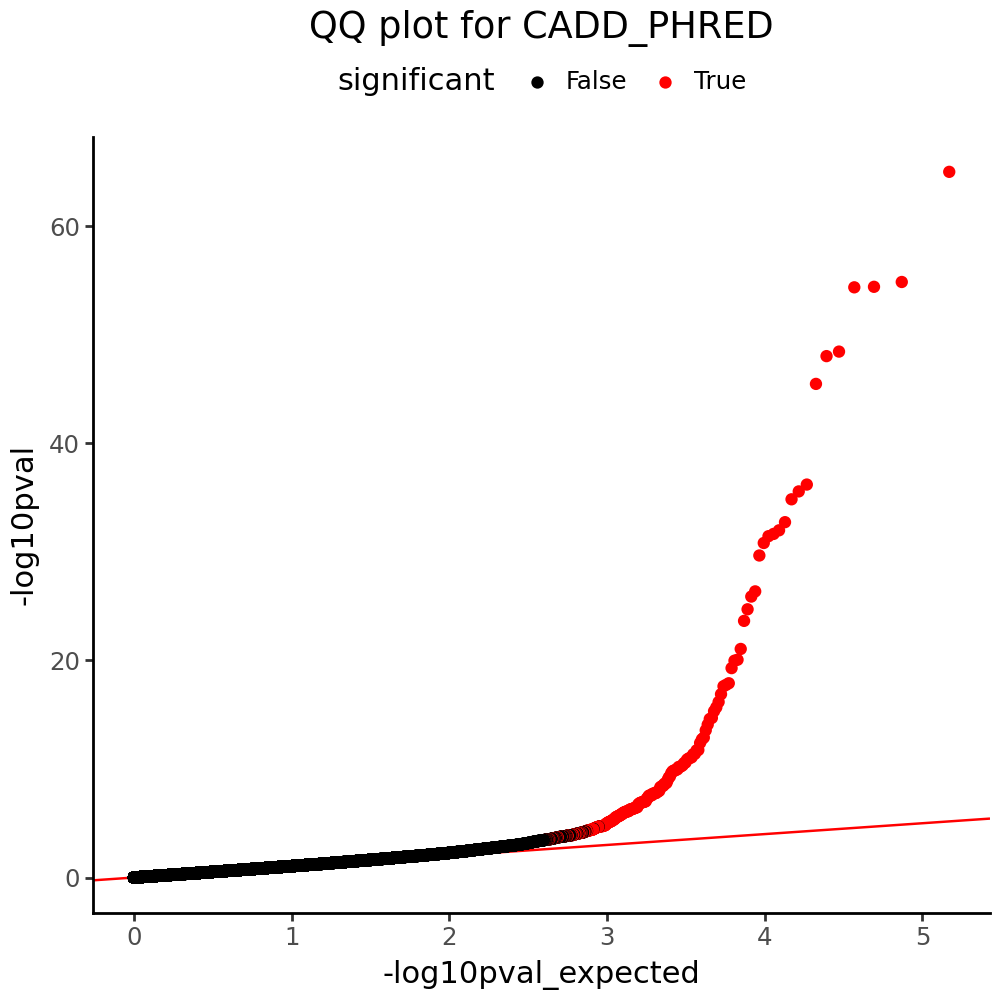

In [52]:
QQ_plot_sig_egenes(df_final, "CADD_PHRED")

[2025-01-28 15:27:01,398] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


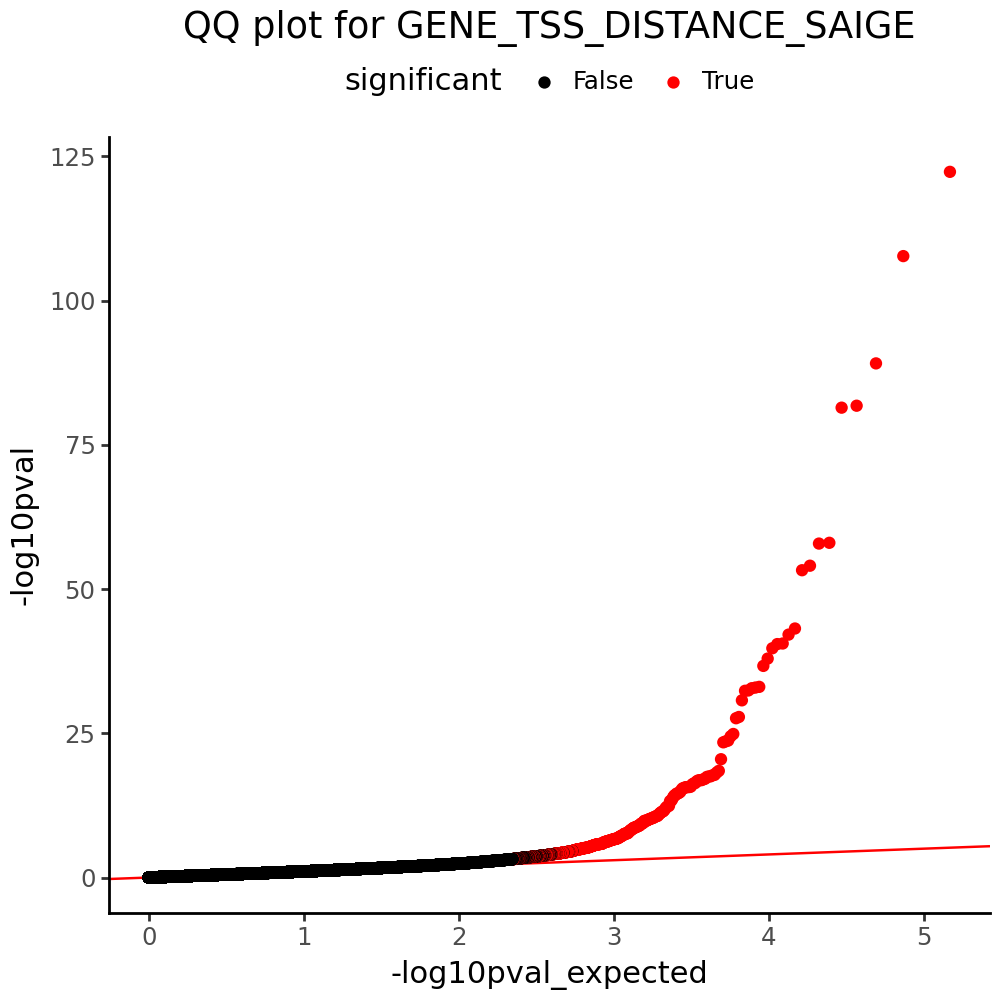

In [51]:
QQ_plot_sig_egenes(df_final, "GENE_TSS_DISTANCE_SAIGE")

[2025-01-28 15:27:32,736] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


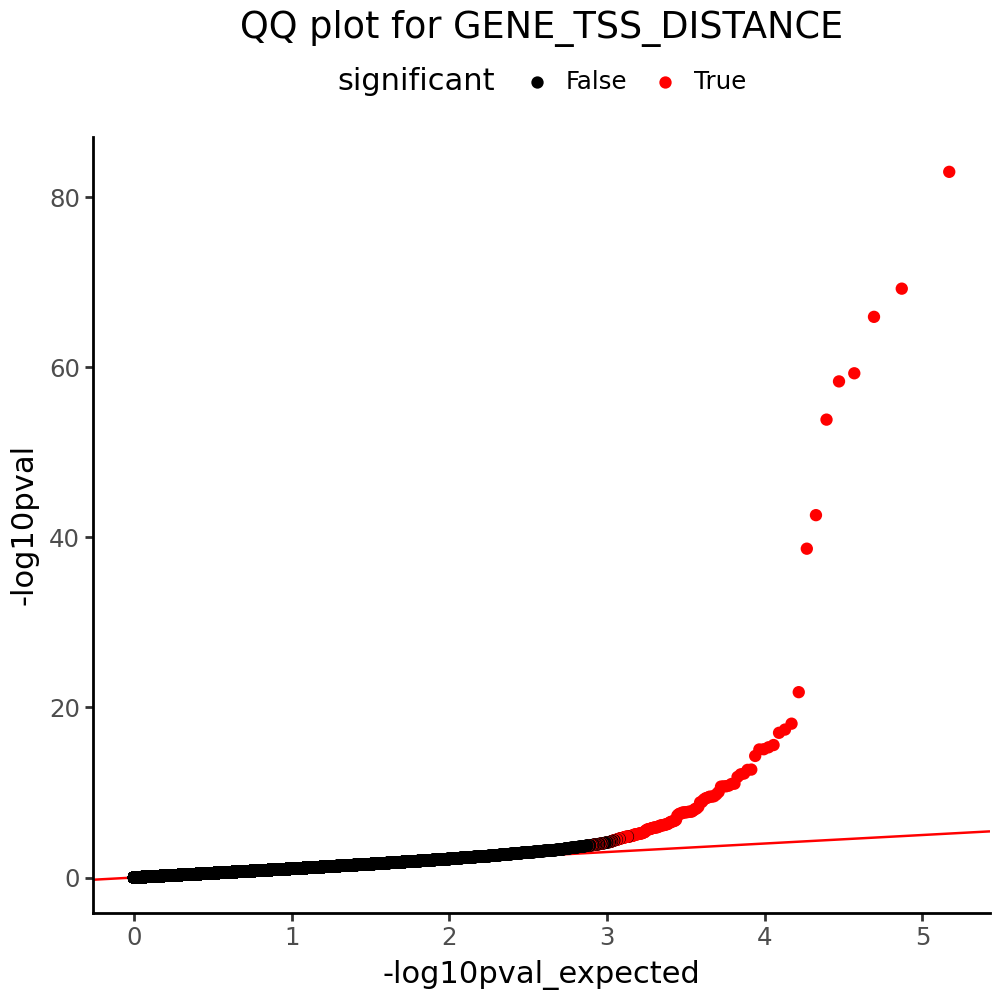

In [53]:
QQ_plot_sig_egenes(df_final, "GENE_TSS_DISTANCE")

[2025-01-28 15:28:52,413] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


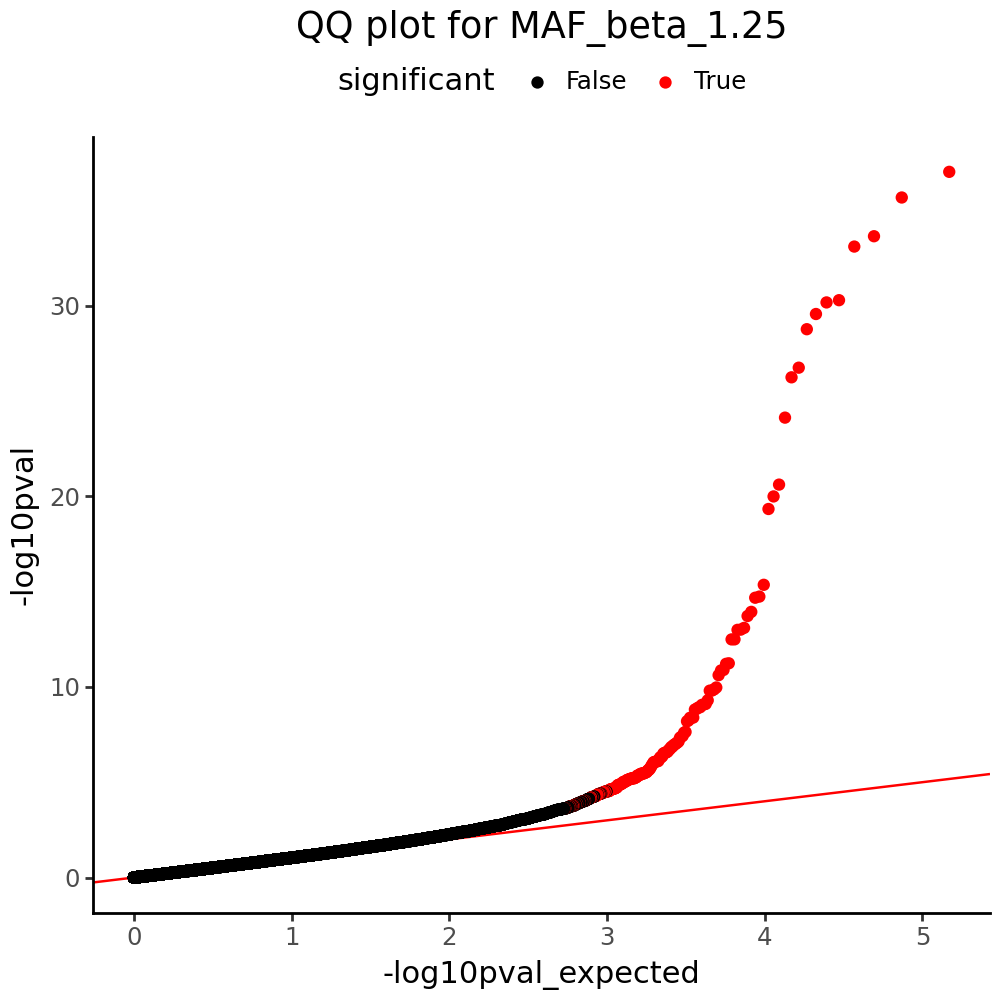

In [56]:
QQ_plot_sig_egenes(df_final, "MAF_beta_1.25")

[2025-01-28 15:29:38,401] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


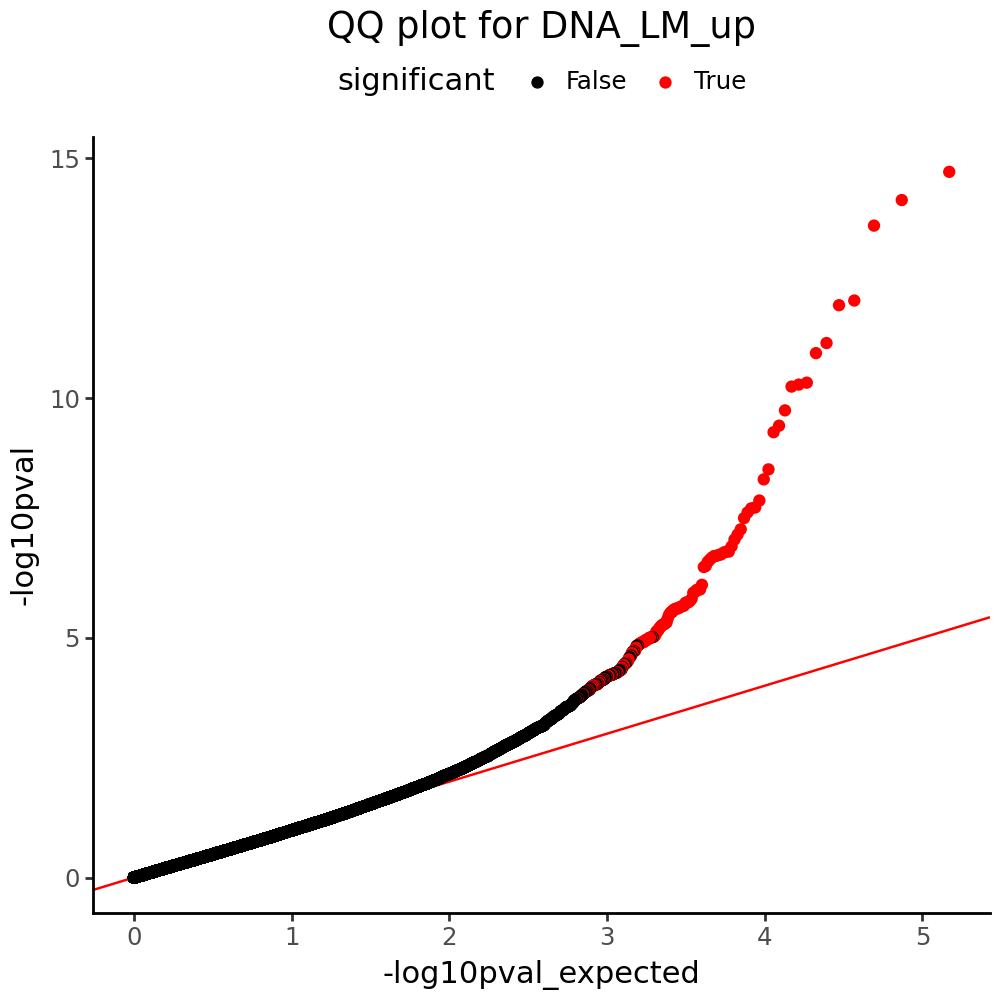

In [57]:
QQ_plot_sig_egenes(df_final, "DNA_LM_up")

[2025-01-28 15:30:14,123] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


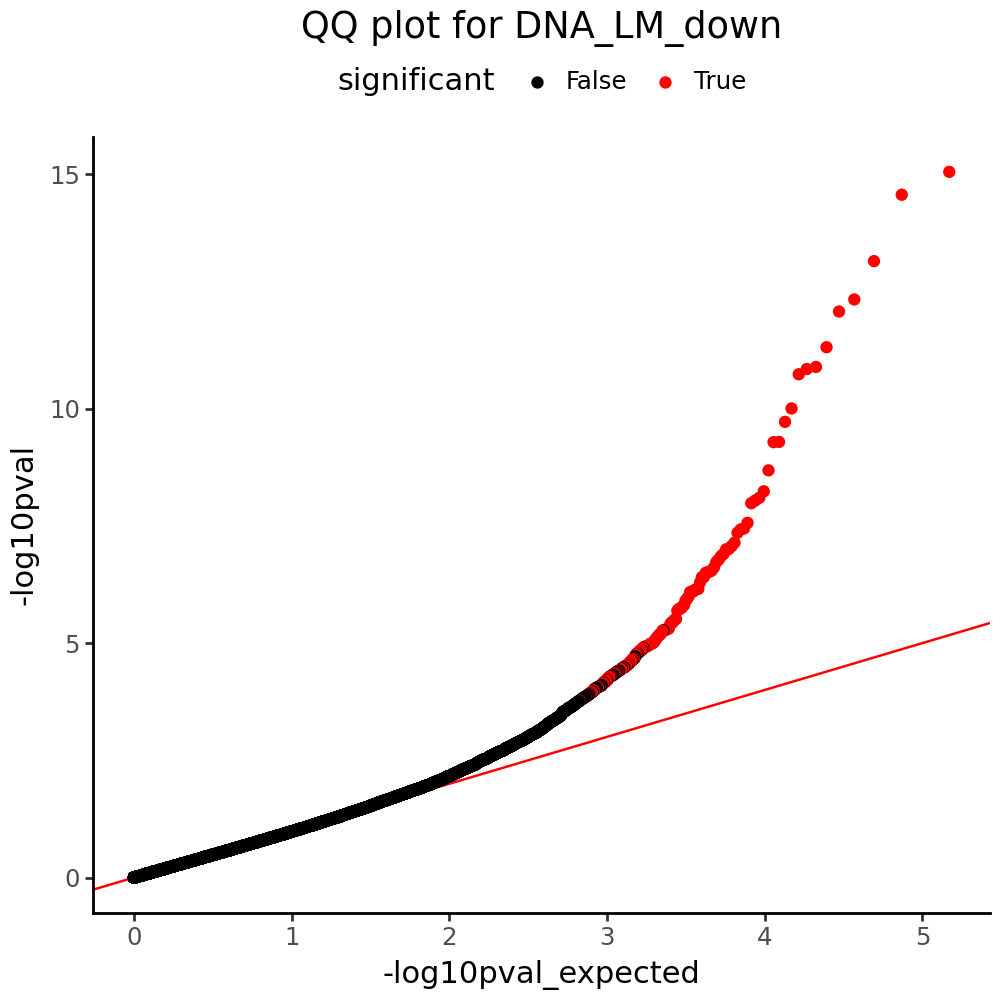

In [58]:
QQ_plot_sig_egenes(df_final, "DNA_LM_down")

[2025-01-28 15:30:53,732] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


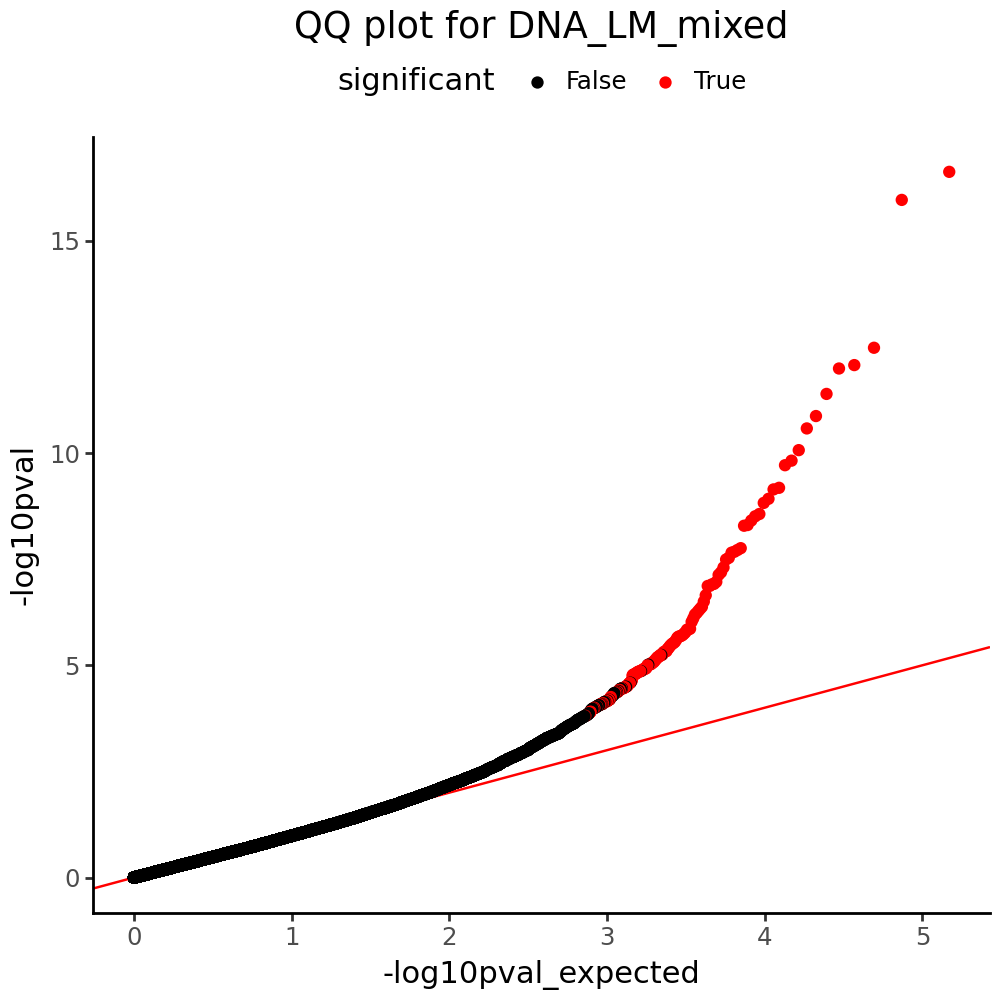

In [59]:
QQ_plot_sig_egenes(df_final, "DNA_LM_mixed")

In [73]:

sum_n_per_annotation = df_to_plot_comb.groupby("annotation")["n"].sum().reset_index()
sum_n_per_annotation

,annotation,n
0,CADD_PHRED,257
1,DNA_LM_down,142
2,DNA_LM_mixed,149
3,DNA_LM_mixed_new,143
4,DNA_LM_up,144
5,GENE_TSS_DISTANCE,147
6,GENE_TSS_DISTANCE_SAIGE,458
7,MAF_beta_1.25,189


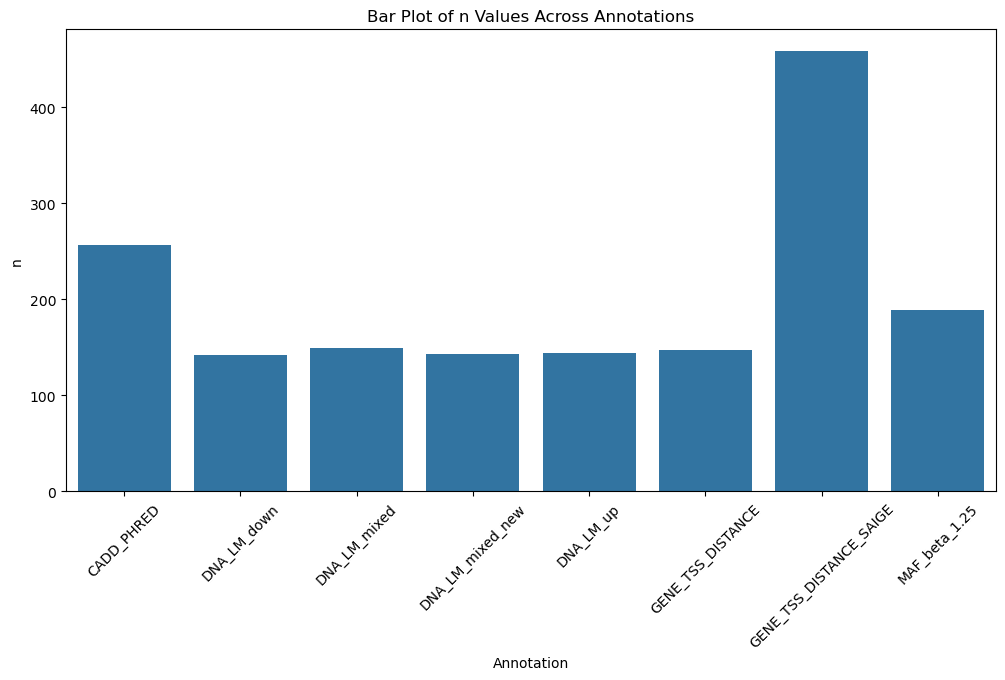

In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = sum_n_per_annotation


# Create the bar plot using seaborn
plt.figure(figsize=(12, 6))
sns.barplot(x="annotation", y="n", data=df_plot)

# Set labels and title
plt.xticks(rotation=45)
plt.xlabel("Annotation")
plt.ylabel("Total number of E-Genes")
plt.title("")

# Show the plot
plt.show()

[2025-01-30 10:45:26,360] INFO:matplotlib.font_manager: Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


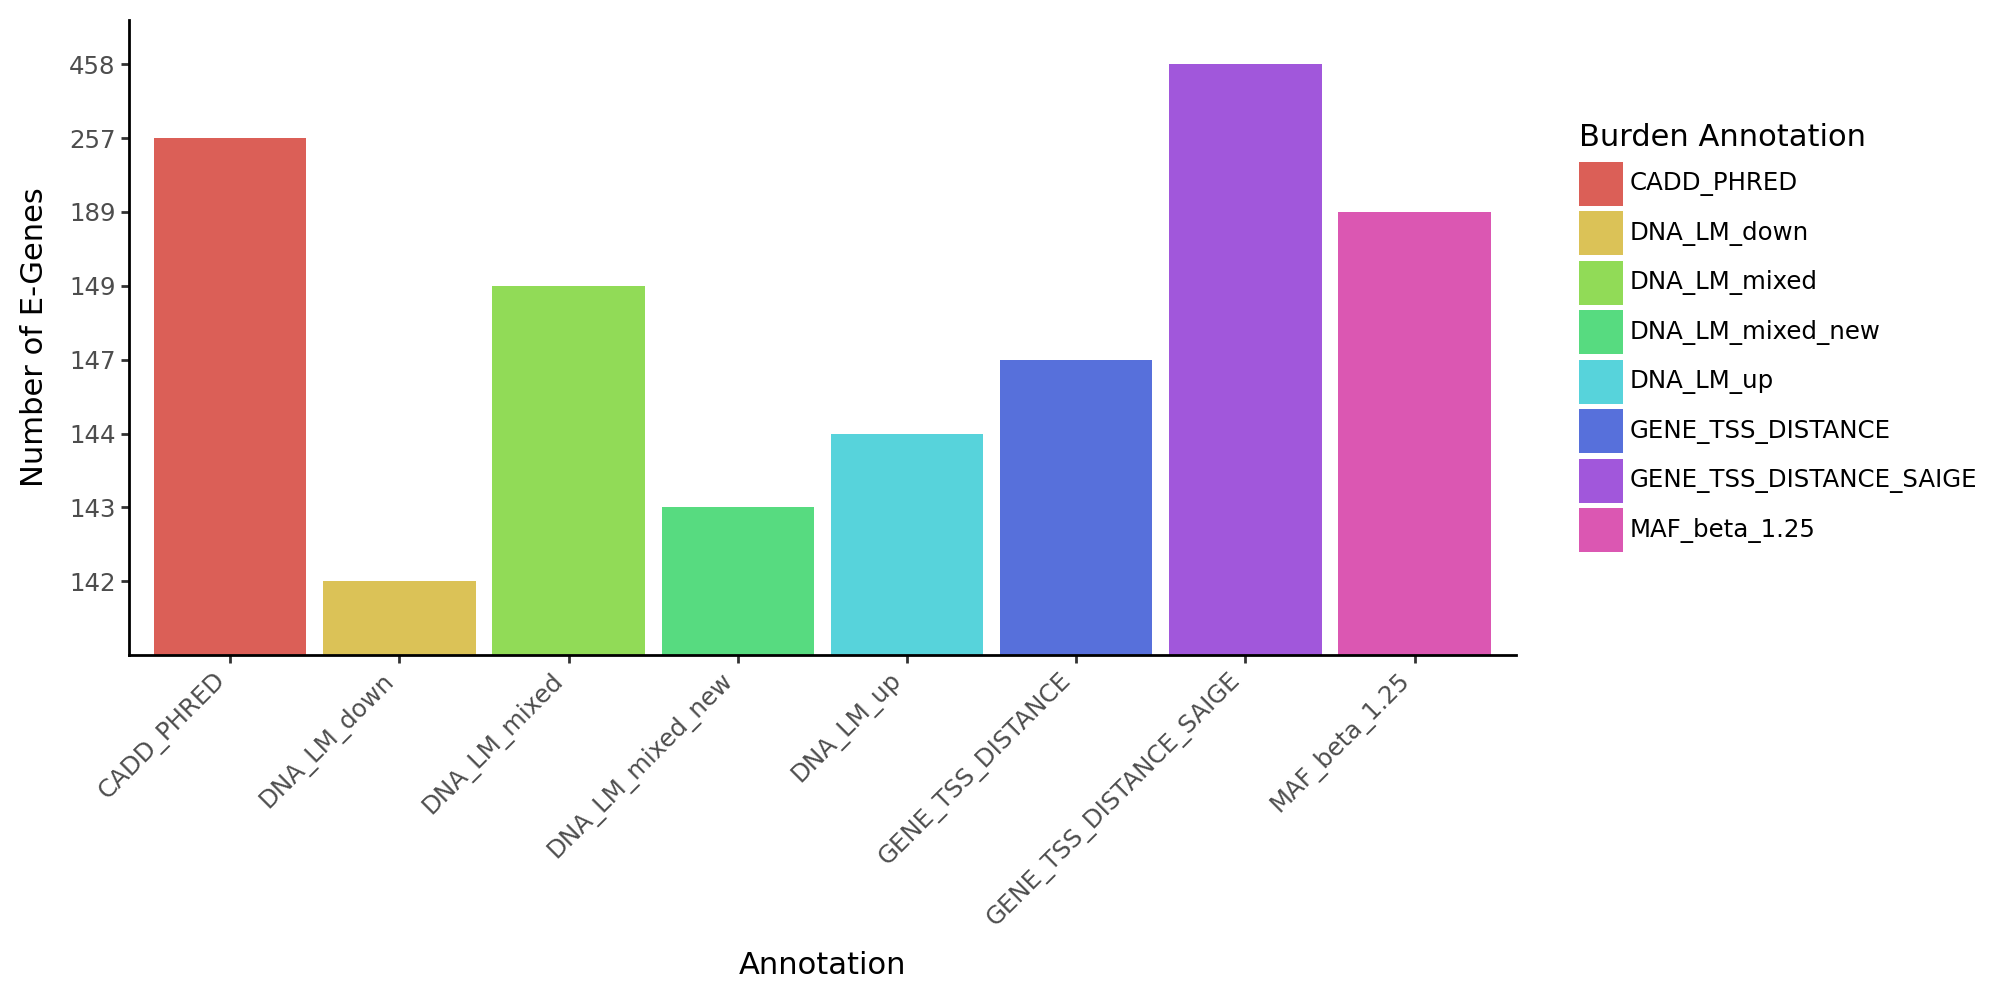

In [104]:
from plotnine import ggplot, aes, geom_bar, theme_classic, theme, element_text, labs, scale_fill_manual, scale_y_discrete

plot = (
    ggplot(df_plot, aes(x='annotation', y='n', fill='annotation'))  
    
    + geom_bar(stat="identity", position="dodge")  
    + theme_classic()  
    + theme(
        axis_text_x=element_text(angle=45, hjust=1, vjust=1),
        figure_size=(10, 5)
    )
    + labs(
        y="Number of E-Genes", 
        x="Annotation", 
        fill="Burden Annotation"
        
    ))

# Display the plot
plot.show()